#Credit card Data Analysis

#Importing required python libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Loading the dataset for analysis

In [ ]:
df=pd.read_csv("/content/creditcard.csv")

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.duplicated().sum()

np.int64(1081)

In [ ]:
df['Class'].unique()

array([0, 1])

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


#removing the duplicates

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

#Visualization

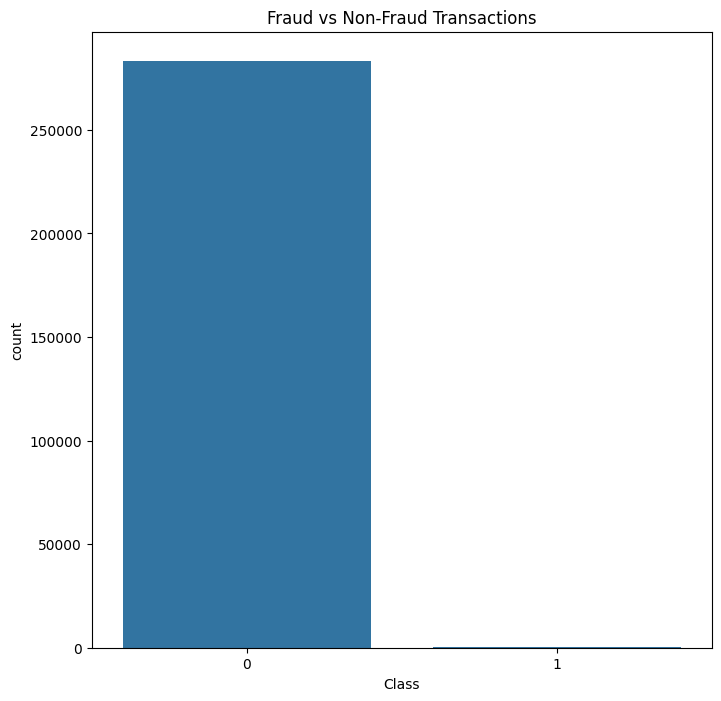

In [ ]:
plt.figure(figsize=(8,8))

sns.countplot(
    x='Class',
    data=df

)

plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

#Standardize the input data

In [ ]:
from sklearn.preprocessing import StandardScaler

scalar=StandardScaler()

df[['Amount','Time']]=scalar.fit_transform(df[['Amount','Time']])

#Spliting the data into input and target

In [ ]:
x=df.drop('Class', axis=1)

In [ ]:
y=df['Class']

# Splitting the Dataset

To evaluate the machine learning model effectively, the dataset is divided into training and testing sets.

- Training Set (80%): Used to train the model.
- Testing Set (20%): Used to evaluate model performance on unseen data.


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#Building Model using  Logistic Regression Algorithm

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, Y_train)


LogisticRegression(max_iter=1000)

In [ ]:
lr_pred = lr.predict(X_test)

#Evaluating the model

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:",
      accuracy_score(Y_test, lr_pred))

print(classification_report(Y_test, lr_pred))

Accuracy: <function accuracy_score at 0x7b8d22f825c0>
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.89      0.53      0.67        90

    accuracy                           1.00     56746
   macro avg       0.94      0.77      0.83     56746
weighted avg       1.00      1.00      1.00     56746



#Building Model using Decision Tree Algorithm

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
dt_pred=dt.predict(X_test)

#Evaluating the model

In [ ]:
print("Accuracy:",
      accuracy_score(Y_test, lr_pred))


Accuracy: 0.9991541254009093


In [ ]:
print(classification_report(Y_test, dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.67      0.71      0.69        90

    accuracy                           1.00     56746
   macro avg       0.83      0.86      0.84     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

#Building Model using Random Forest Algorithm

In [ ]:
rf_pred=rf.predict(X_test)

#Evaluating the model

In [ ]:
print('Accuracy', accuracy_score(Y_test,rf_pred))

Accuracy 0.9995418179254926


In [ ]:
print("Classification Report:", classification_report(Y_test,rf_pred))

Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.97      0.73      0.84        90

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



#Comparing the Accuracy of all the models


In [ ]:
lr_acc = accuracy_score(Y_test, lr_pred)
dt_acc = accuracy_score(Y_test, dt_pred)
rf_acc = accuracy_score(Y_test, rf_pred)

import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
2,Random Forest,0.999542
0,Logistic Regression,0.999154
1,Decision Tree,0.998978


##Limitation

Due to the severe class imbalance in the dataset, model accuracy alone may not be sufficient for evaluation. Although the Random Forest model achieved high accuracy, some fraudulent transactions may still go undetected. Techniques such as SMOTE can be applied to improve fraud detection performance.

##Aplying SMOTE to overcome the imbalanced data

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(x, y)


In [ ]:
pd.Series(y_resampled).value_counts()

,count
Class,
0,283253
1,283253


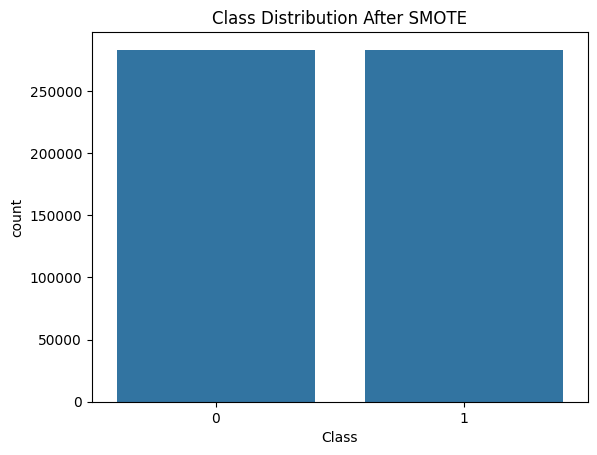

In [ ]:
sns.countplot(x=y_resampled)

plt.title("Class Distribution After SMOTE")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

#Building the model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)



In [ ]:
rf_pred = rf.predict(X_test)

#Evaluating the model

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56463
           1       1.00      1.00      1.00     56839

    accuracy                           1.00    113302
   macro avg       1.00      1.00      1.00    113302
weighted avg       1.00      1.00      1.00    113302



The original dataset was highly imbalanced, with fraudulent transactions representing a very small percentage of the data. To address this issue, SMOTE was applied to generate synthetic fraud samples and balance the classes. After balancing, the Random Forest classifier achieved perfect precision, recall, and F1-score, demonstrating the effectiveness of class balancing techniques in fraud detection tasks.

##Conclusion


A fraud detection system was developed using machine learning techniques to identify fraudulent transactions. Data preprocessing included duplicate removal, feature scaling, and class balancing using SMOTE. Logistic Regression, Decision Tree, and Random Forest classifiers were trained and evaluated. Random Forest achieved the best performance. The system demonstrates the effectiveness of machine learning for anomaly detection and fraud prevention and can be extended for real-time monitoring and large-scale transaction processing.